In [2]:
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import CubicSpline

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_rows',100)

In [4]:
subject_pupil_2 = pd.read_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Items\subject_67_Task_epocs.csv")

In [5]:
subject_pupil_1.CorrResponse.unique()

array([2, 1], dtype=int64)

In [107]:
subject_pupil_1_transposed = subject_pupil_1[subject_pupil_1.columns[6:8006]].T

In [108]:
missing_values_df = pd.DataFrame(subject_pupil_1_transposed.isnull().sum()/8000).reset_index()
to_drop_trials = list(missing_values_df[missing_values_df[0]>=0.80]['index'])

In [104]:
subject_pupil_1_transposed.drop(columns = to_drop_trials,inplace=True)

In [105]:
subject_pupil_1_transposed

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
Pupil_1_1,NaN,-1.379452,-0.019267,NaN,-0.881697,0.440348,0.717400,NaN,0.194613,0.349257,...,-0.900891,0.027825,1.967270,-0.083382,0.199556,1.063403,-2.306259,-0.525561,-0.415491,0.688629
Pupil_1_2,NaN,-1.374303,-0.018442,NaN,-0.883615,0.440379,0.717344,NaN,0.193643,0.347081,...,-0.902131,0.028694,1.964764,-0.081979,0.203884,1.065449,-2.308224,-0.527693,-0.421715,0.693219
Pupil_1_3,NaN,-1.369150,-0.017614,NaN,-0.885537,0.440435,0.717274,NaN,0.192677,0.344920,...,-0.903374,0.029574,1.962258,-0.080569,0.208177,1.067485,-2.310144,-0.529817,-0.427908,0.697765
Pupil_1_4,NaN,-1.363993,-0.016783,NaN,-0.887462,0.440516,0.717190,NaN,0.191715,0.342775,...,-0.904618,0.030463,1.959753,-0.079151,0.212437,1.069510,-2.312018,-0.531931,-0.434070,0.702265
Pupil_1_5,NaN,-1.358833,-0.015951,NaN,-0.889390,0.440623,0.717091,NaN,0.190757,0.340647,...,-0.905865,0.031362,1.957249,-0.077726,0.216664,1.071525,-2.313847,-0.534036,-0.440201,0.706721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pupil_1_7996,-2.050835,NaN,NaN,-0.651210,-0.072782,0.908891,NaN,-0.227012,0.470902,-0.199955,...,0.879650,1.036947,0.403839,0.709350,-0.318255,-1.354647,-0.388932,0.014902,0.771465,0.028106
Pupil_1_7997,-2.046218,NaN,NaN,-0.654035,-0.073132,0.909100,NaN,-0.228383,0.468936,-0.201765,...,0.880435,1.035431,0.405573,0.711811,-0.314821,-1.356564,-0.392470,0.008476,0.777946,0.029681
Pupil_1_7998,-2.041589,NaN,NaN,-0.656875,-0.073465,0.909298,NaN,-0.229747,0.466971,-0.203569,...,0.881232,1.033913,0.407318,0.714255,-0.311401,-1.358453,-0.395991,0.002054,0.784393,0.031250
Pupil_1_7999,-2.036949,NaN,NaN,-0.659732,-0.073781,0.909486,NaN,-0.231105,0.465010,-0.205368,...,0.882040,1.032394,0.409074,0.716683,-0.307996,-1.360312,-0.399497,-0.004365,0.790803,0.032812


In [247]:
def fill_in_first_missing(subject_pupil_1_filtered):
    # trials with first timestamp value missing
    trials_pupil_1_missing = subject_pupil_1_filtered[subject_pupil_1_filtered['Pupil_1_1'].isnull()]
    
    #trials with first timestamp value not missing
    trials_pupil_1_not_missing = subject_pupil_1_filtered[~subject_pupil_1_filtered['Pupil_1_1'].isnull()]
    first_timestamp_mean_value = trials_pupil_1_not_missing.Pupil_1_1.mean()
    
    # imputing first timestamp missing 
    trials_pupil_1_missing_transposed = trials_pupil_1_missing.T
    for trial in trials_pupil_1_missing_transposed.columns:
        array_trail_data = np.array(trials_pupil_1_missing_transposed[trial])
        first_non_missing_index = np.where(~np.isnan(array_trail_data[1:]))[0][0]+1
        array_trail_data[2:first_non_missing_index] = array_trail_data[first_non_missing_index]
        array_trail_data[1] = first_timestamp_mean_value
        trials_pupil_1_missing_transposed[trial] = list(array_trail_data)
        
    # getting back the original dataframe
    trials_pupil_1_first_filled = trials_pupil_1_missing_transposed.T
    subject_pupil_1 = pd.concat([trials_pupil_1_first_filled,trials_pupil_1_not_missing])
    return subject_pupil_1

In [248]:
def fill_in_last_missing(subject_pupil_1_filtered):
    # trials with last timestamp value missing
    trials_pupil_1_missing = subject_pupil_1_filtered[subject_pupil_1_filtered['Pupil_1_8000'].isnull()]
    
    #trials with last timestamp value not missing
    trials_pupil_1_not_missing = subject_pupil_1_filtered[~subject_pupil_1_filtered['Pupil_1_8000'].isnull()]
    
    # imputing first timestamp missing 
    trials_pupil_1_missing_transposed = trials_pupil_1_missing.T
    for trial in trials_pupil_1_missing_transposed.columns:
        array_trail_data = np.array(trials_pupil_1_missing_transposed[trial])
        last_non_missing_index = np.where(~np.isnan(array_trail_data[1:]))[0][-1]+1
        array_trail_data[last_non_missing_index+1:] = array_trail_data[last_non_missing_index]
        trials_pupil_1_missing_transposed[trial] = list(array_trail_data)
        
    # getting back the original dataframe
    trials_pupil_1_first_filled = trials_pupil_1_missing_transposed.T
    subject_pupil_1 = pd.concat([trials_pupil_1_first_filled,trials_pupil_1_not_missing])
    return subject_pupil_1

In [249]:
def cubic_Spline_interpolation(subject_pupil_1_transposed):
    for trial in subject_pupil_1_transposed.columns:
        array_pupils = np.array(subject_pupil_1_transposed[trial])
        missing_indices = np.isnan(array_pupils)

        non_missing_indices = np.where(~missing_indices)[0]
        non_missing_values = array_pupils[non_missing_indices]

        cubic_spline = CubicSpline(non_missing_indices, non_missing_values, bc_type='natural')

        interpolated_values = cubic_spline(np.where(missing_indices)[0])

        array_pupils[missing_indices] = interpolated_values

        subject_pupil_1_transposed[trial] = array_pupils
        
    return subject_pupil_1_transposed.T

In [250]:
def check_drop_trailing_missing(subject_pupil_1):
#     trailing_columns = subject_pupil_1.columns[5500:]
#     subject_pupil_1_transposed = subject_pupil_1[trailing_columns].T
#     missing_values_df = pd.DataFrame(subject_pupil_1_transposed.isnull().sum()/2501).reset_index()
#     to_drop_trials = list(missing_values_df[missing_values_df[0]>=0.75]['index'])
#     to_drop_trials = [i+1 for i in to_drop_trials]
#     subject_pupil_1 = subject_pupil_1[~subject_pupil_1['Trial'].isin(to_drop_trials)]
    to_drop_trials = subject_pupil_1[subject_pupil_1['Pupil_1_8000'].isnull()]['Trial']
    subject_pupil_1 = subject_pupil_1[~subject_pupil_1['Trial'].isin(to_drop_trials)]
    return subject_pupil_1

In [251]:
main_pupils_df = pd.DataFrame(columns = ['Trial']+list(subject_pupil_2.columns[6:8006])+['Subject_ID','ADHD_Identifier'])
for i in range(1,68):
    print(i)
    subject_pupil_1 = pd.read_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Items\subject_"+str(i)+"_Task_epocs.csv",usecols= ['Trial']+list(subject_pupil_2.columns[6:8006]))
    
    # checking for trials with more than 80% missing
    subject_pupil_1_transposed = subject_pupil_1.T
    missing_values_df = pd.DataFrame(subject_pupil_1_transposed.isnull().sum()/8001).reset_index()
    to_drop_trials = list(missing_values_df[missing_values_df[0]>=0.80]['index'])
    subject_pupil_1_transposed.drop(columns = to_drop_trials,inplace=True)
    subject_pupil_1_filtered = subject_pupil_1_transposed.T
    
    #filling records with first timestamp value missing
    subject_pupil_1 = fill_in_first_missing(subject_pupil_1_filtered)
    #filling records with last timestamp value missing
    #subject_pupil_1 = fill_in_last_missing(subject_pupil_1)
    subject_pupil_1 = check_drop_trailing_missing(subject_pupil_1)
    
    ##filling remaining missing records with cubic spline
    subject_pupil_1 = cubic_Spline_interpolation(subject_pupil_1.T)
    
    subject_pupil_1['Subject_ID'] = i
    if i<=28:
        subject_pupil_1['ADHD_Identifier'] = 'ADHD'
    elif i<=45:
        subject_pupil_1['ADHD_Identifier'] = 'mADHD'
    else:
        subject_pupil_1['ADHD_Identifier'] = 'NoADHD'
        
    main_pupils_df = pd.concat([main_pupils_df,subject_pupil_1])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67


In [92]:
main_pupils_df.shape

(7950, 8003)

In [61]:
main_pupils_df.isnull().sum()

Trial              0
Pupil_1_1          0
Pupil_1_2          0
Pupil_1_3          0
Pupil_1_4          0
                  ..
Pupil_1_7998       0
Pupil_1_7999       0
Pupil_1_8000       0
Subject_ID         0
ADHD_Identifier    0
Length: 8003, dtype: int64

### MADHD - PROBLEM

In [224]:
main_pupils_df[main_pupils_df['ADHD_Identifier']=='mADHD']

,Trial,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,...,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000,Subject_ID,ADHD_Identifier
20,21.0,2.936717,2.936717,2.936717,2.936717,2.936717,2.936717,2.936717,2.936717,2.936717,...,-0.688382,-0.688382,-0.688382,-0.688382,-0.688382,-0.688382,-0.688382,-0.688382,29,mADHD
25,26.0,-0.084621,-0.084621,-0.084621,-0.084621,-0.084621,-0.084621,-0.084621,-0.084621,-0.084621,...,0.388067,0.388067,0.388067,0.388067,0.388067,0.388067,0.388067,0.388067,29,mADHD
40,41.0,-1.95147,-1.95147,-1.95147,-1.95147,-1.95147,-1.95147,-1.95147,-1.95147,-1.95147,...,-1.945747,-1.945747,-1.945747,-1.945747,-1.945747,-1.945747,-1.945747,-1.945747,29,mADHD
44,45.0,-1.983875,-1.983875,-1.983875,-1.983875,-1.983875,-1.983875,-1.983875,-1.983875,-1.983875,...,0.462912,0.462912,0.462912,0.462912,0.462912,0.462912,0.462912,0.462912,29,mADHD
73,74.0,1.715998,1.715998,1.715998,1.715998,1.715998,1.715998,1.715998,1.715998,1.715998,...,0.388668,0.388668,0.388668,0.388668,0.388668,0.388668,0.388668,0.388668,29,mADHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,155.0,-0.61587,-0.61504,-0.614198,-0.613342,-0.612473,-0.61159,-0.610693,-0.609782,-0.608857,...,-0.437104,-0.43904,-0.440964,-0.442875,-0.444773,-0.446659,-0.448532,-0.450392,45,mADHD
155,156.0,-1.068634,-1.070633,-1.072617,-1.074586,-1.076542,-1.078484,-1.080411,-1.082325,-1.084225,...,-1.897121,-1.897506,-1.897897,-1.898293,-1.898693,-1.899099,-1.899509,-1.899924,45,mADHD
156,157.0,-1.534216,-1.534748,-1.535282,-1.535815,-1.536349,-1.536883,-1.537416,-1.537949,-1.53848,...,0.709569,0.708911,0.708208,0.707459,0.706663,0.705822,0.704934,0.704,45,mADHD
157,158.0,0.236713,0.235233,0.233715,0.232159,0.230564,0.228931,0.22726,0.225551,0.223804,...,-0.73122,-0.73748,-0.743686,-0.749836,-0.755933,-0.761975,-0.767962,-0.773896,45,mADHD


In [237]:
madhd_original_data = pd.DataFrame(columns= ['Trial']+list(subject_pupil_2.columns[6:506])+['Subject_ID'])
for i in range(29,46):
    subject_pupil_1 = pd.read_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Items\subject_"+str(i)+"_Task_epocs.csv",usecols= ['Trial']+list(subject_pupil_2.columns[6:506]))
    subject_pupil_1['Subject_ID'] = i
    
    madhd_original_data = pd.concat([madhd_original_data,subject_pupil_1])

In [238]:
madhd_original_data.shape

(2720, 502)

In [239]:
madhd_original_data.head()

,Trial,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,...,Pupil_1_492,Pupil_1_493,Pupil_1_494,Pupil_1_495,Pupil_1_496,Pupil_1_497,Pupil_1_498,Pupil_1_499,Pupil_1_500,Subject_ID
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29
1,2,0.146642,0.134186,0.121732,0.10928,0.096832,0.084391,0.071957,0.059532,0.047118,...,-0.728617,-0.725161,-0.721717,-0.718286,-0.714868,-0.711464,-0.708074,-0.704699,-0.701339,29
2,3,0.661891,0.661386,0.660871,0.660345,0.659809,0.659262,0.658706,0.658139,0.657563,...,0.211974,0.208988,0.206037,0.203124,0.20025,0.197416,0.194623,0.191874,0.18917,29
3,4,-0.085853,-0.085663,-0.085473,-0.085283,-0.085094,-0.084905,-0.084717,-0.084529,-0.084342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29
4,5,-0.530982,-0.533634,-0.536336,-0.53909,-0.541894,-0.544749,-0.547654,-0.550609,-0.553614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29


In [178]:
main_pupils_df.groupby(by=['Subject_ID']).agg({'Trial':'count'}).reset_index()

,Subject_ID,Trial
0,1,151
1,2,147
2,3,144
3,4,138
4,5,152
5,6,144
6,7,149
7,8,126
8,9,150
9,10,135


In [6]:
main_pupils_df

,Trial,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,...,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000,Subject_ID,ADHD_Identifier
0,1.0,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,...,-2.064614,-2.060034,-2.055441,-2.050835,-2.046218,-2.041589,-2.036949,-2.032298,1,ADHD
1,4.0,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,...,-0.642837,-0.645611,-0.648402,-0.651210,-0.654035,-0.656875,-0.659732,-0.662603,1,ADHD
2,8.0,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,...,-0.222863,-0.224252,-0.225635,-0.227012,-0.228383,-0.229747,-0.231105,-0.232458,1,ADHD
3,46.0,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,...,-1.654918,-1.655608,-1.656315,-1.657039,-1.657779,-1.658536,-1.659309,-1.660098,1,ADHD
4,62.0,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,...,-0.725234,-0.730251,-0.735253,-0.740238,-0.745206,-0.750157,-0.755090,-0.760004,1,ADHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6985,155.0,-1.079020,-1.079678,-1.080334,-1.080989,-1.081642,-1.082294,-1.082943,-1.083591,-1.084238,...,-0.354448,-0.355677,-0.356903,-0.358127,-0.359348,-0.360567,-0.361783,-0.362997,67,NoADHD
6986,156.0,-1.042429,-1.044024,-1.045618,-1.047211,-1.048803,-1.050395,-1.051986,-1.053576,-1.055167,...,1.788020,1.786976,1.785966,1.784989,1.784045,1.783134,1.782256,1.781412,67,NoADHD
6987,157.0,1.635427,1.635256,1.635104,1.634972,1.634859,1.634766,1.634691,1.634635,1.634597,...,-0.763238,-0.761298,-0.759357,-0.757414,-0.755468,-0.753521,-0.751571,-0.749620,67,NoADHD
6988,158.0,-1.389628,-1.387164,-1.384694,-1.382220,-1.379740,-1.377255,-1.374764,-1.372268,-1.369767,...,-1.258690,-1.257325,-1.255967,-1.254617,-1.253274,-1.251939,-1.250612,-1.249293,67,NoADHD


In [33]:
temp.T

,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,Pupil_1_10,...,Pupil_1_7991,Pupil_1_7992,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000
0,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,...,-2.073733,-2.069180,-2.064614,-2.060034,-2.055441,-2.050835,-2.046218,-2.041589,-2.036949,-2.032298
1,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,...,-0.637345,-0.640082,-0.642837,-0.645611,-0.648402,-0.651210,-0.654035,-0.656875,-0.659732,-0.662603
2,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,...,-0.220065,-0.221467,-0.222863,-0.224252,-0.225635,-0.227012,-0.228383,-0.229747,-0.231105,-0.232458
3,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,...,-1.653587,-1.654244,-1.654918,-1.655608,-1.656315,-1.657039,-1.657779,-1.658536,-1.659309,-1.660098
4,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,...,-0.715153,-0.720201,-0.725234,-0.730251,-0.735253,-0.740238,-0.745206,-0.750157,-0.755090,-0.760004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,1.063403,1.065449,1.067485,1.069510,1.071525,1.073529,1.075522,1.077503,1.079472,1.081429,...,-1.344632,-1.346692,-1.348724,-1.350727,-1.352701,-1.354647,-1.356564,-1.358453,-1.360312,-1.362143
141,-2.306259,-2.308224,-2.310144,-2.312018,-2.313847,-2.315630,-2.317368,-2.319061,-2.320709,-2.322312,...,-0.371013,-0.374628,-0.378228,-0.381811,-0.385380,-0.388932,-0.392470,-0.395991,-0.399497,-0.402988
142,-0.525561,-0.527693,-0.529817,-0.531931,-0.534036,-0.536133,-0.538221,-0.540300,-0.542372,-0.544436,...,0.047055,0.040624,0.034192,0.027761,0.021331,0.014902,0.008476,0.002054,-0.004365,-0.010780
143,-0.415491,-0.421715,-0.427908,-0.434070,-0.440201,-0.446299,-0.452367,-0.458402,-0.464406,-0.470378,...,0.738587,0.745219,0.751825,0.758402,0.764949,0.771465,0.777946,0.784393,0.790803,0.797175


<AxesSubplot:>

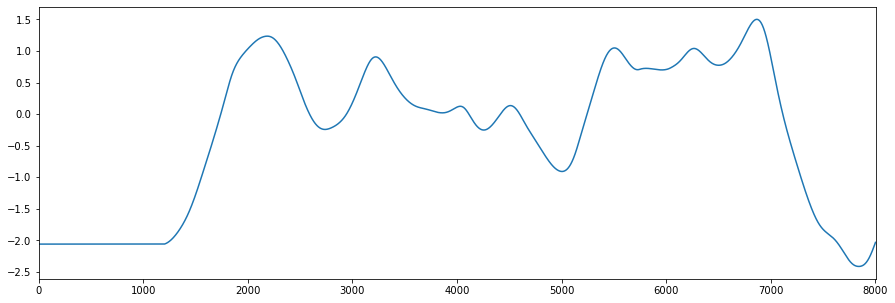

In [35]:
temp = main_pupils_df[main_pupils_df['Subject_ID']==1].drop(columns=['Trial','Subject_ID','ADHD_Identifier'])
temp.columns = list(range(1,8001))
temp = temp.T
temp[0].plot(xlim= (0,8001),figsize=(15,5))

In [193]:
agg_dict = {}
for col in list(subject_pupil_2.columns[6:8006]):
    agg_dict[col]='mean'
grouped_identifiers = main_pupils_df.groupby('ADHD_Identifier').agg(agg_dict)

In [198]:
grouped_identifiers.T.to_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\grouped_identifiers.csv",index=True)

In [197]:
grouped_identifiers.T

ADHD_Identifier,ADHD,NoADHD,mADHD
Pupil_1_1,-0.290102,-0.517539,-0.419892
Pupil_1_2,-0.290335,-0.517725,-0.437091
Pupil_1_3,-0.289610,-0.517910,-0.448653
Pupil_1_4,-0.289268,-0.518094,-0.464712
Pupil_1_5,-0.288964,-0.518007,-0.481370
...,...,...,...
Pupil_1_7996,-0.297035,-0.525267,-0.431898
Pupil_1_7997,-0.297580,-0.525593,-0.432424
Pupil_1_7998,-0.298123,-0.525919,-0.432947
Pupil_1_7999,-0.298664,-0.526247,-0.433470


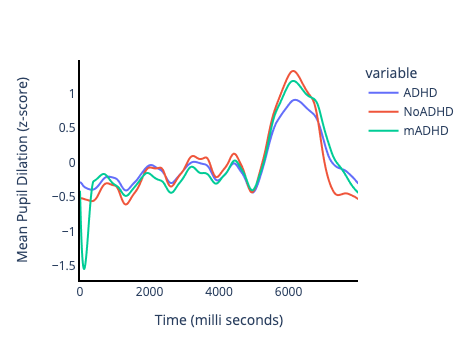

In [223]:
import plotly.express as px
import pandas as pd

# Use plotly express to create a line plot
fig = px.line(grouped_identifiers.T, x=list(range(8000)), y=['ADHD','NoADHD','mADHD'],
             labels={'value': 'Mean Pupil Dilation (z-score)', 'x': 'Time (milli seconds)'})

fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(showline=True, linewidth=2, linecolor='black')
fig.update_yaxes(showline=True, linewidth=2, linecolor='black')

# Show the plot
fig.show()

In [201]:
agg_dict = {}
for col in list(subject_pupil_2.columns[6:8006]):
    agg_dict[col]='mean'
grouped_identifiers_2 = main_pupils_df.groupby(['ADHD_Identifier','Trial']).agg(agg_dict)

In [203]:
grouped_identifiers_2.reset_index(inplace=True)

In [215]:
grouped_identifiers_2.T.to_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\grouped_identifiers_2.csv",index=True)

### EXCLUDING MADHD

In [255]:
main_pupils_df[main_pupils_df['ADHD_Identifier']!='mADHD'].to_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Pupils_without_mADHD.csv",index=False)

In [5]:
pupils_df = pd.read_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Pupils_without_mADHD.csv")

In [6]:
pupils_df.shape

(5751, 8003)

### MODELING 1 - BASE LOGISTIC REGRESSION

In [96]:
le = LabelEncoder()
pupils_df['ADHD_Identifier'] = le.fit_transform(pupils_df['ADHD_Identifier'])

In [251]:
pupils_df.head()

,Trial,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,...,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000,Subject_ID,ADHD_Identifier
0,21.0,-1.582969,-1.582969,-1.582969,-1.582969,-1.582969,-1.582969,-1.582969,-1.582969,-1.582969,...,0.552978,0.552978,0.552978,0.552978,0.552978,0.552978,0.552978,0.552978,1,0
1,41.0,-1.368047,-1.368047,-1.368047,-1.368047,-1.368047,-1.368047,-1.368047,-1.368047,-1.368047,...,0.467771,0.467771,0.467771,0.467771,0.467771,0.467771,0.467771,0.467771,1,0
2,61.0,-0.115880,-0.115880,-0.115880,-0.115880,-0.115880,-0.115880,-0.115880,-0.115880,-0.115880,...,-0.818158,-0.818158,-0.818158,-0.818158,-0.818158,-0.818158,-0.818158,-0.818158,1,0
3,81.0,-3.548643,-3.548643,-3.548643,-3.548643,-3.548643,-3.548643,-3.548643,-3.548643,-3.548643,...,0.918575,0.918575,0.918575,0.918575,0.918575,0.918575,0.918575,0.918575,1,0
4,101.0,1.346613,1.346613,1.346613,1.346613,1.346613,1.346613,1.346613,1.346613,1.346613,...,-1.437307,-1.437307,-1.437307,-1.437307,-1.437307,-1.437307,-1.437307,-1.437307,1,0


In [97]:
x_train, x_test, y_train, y_test = train_test_split(pupils_df[pupils_df.columns[1:-2]], pupils_df['ADHD_Identifier'], test_size=0.25)

In [98]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [99]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.69      0.69       759
           1       0.66      0.67      0.66       679

    accuracy                           0.68      1438
   macro avg       0.68      0.68      0.68      1438
weighted avg       0.68      0.68      0.68      1438



### MODELLING -2 - PCA + LOGISTIC REGRESSION

In [263]:
from sklearn.decomposition import PCA

In [319]:
pca = PCA(n_components = 9)

In [320]:
pca.fit(pupils_df[pupils_df.columns[1:-2]])

PCA(n_components=9)

In [321]:
sum(pca.explained_variance_ratio_)

0.929981231924985

In [322]:
x = pd.DataFrame(pca.fit_transform(pupils_df[pupils_df.columns[1:-2]]))

In [323]:
x_train, x_test, y_train, y_test = train_test_split(x, pupils_df['ADHD_Identifier'], test_size=0.25)

In [324]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [326]:
y_train_pred = lr.predict(x_train)

In [328]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.74      0.72      1024
           1       0.63      0.59      0.61       789

    accuracy                           0.67      1813
   macro avg       0.67      0.66      0.66      1813
weighted avg       0.67      0.67      0.67      1813



### FEATURE ENGG -1

In [37]:
pupils_df = pd.read_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\Pupils_without_mADHD.csv")

In [112]:
pupils_df.reset_index(inplace=True)

In [7]:
pupils_df_t = pupils_df.T

In [8]:
feature_baseline_start, feature_baseline_end = [],[]
feature_peak_pre5000, feature_peak_post5000 = [],[]
adhd_identifier = []
distances, velocities_post5000, accelerations_post5000 = [],[],[]
difference_peak_baseline = []

def find_maximum(peaks, values):
    max_value = -1000
    for peak_index in peaks:
        local_maxima = values[peak_index]
        if max_value<local_maxima:
            max_value = local_maxima
    return (max_value)

def find_velocities(values):
    velocities,accelerations = [],[]
    values = values-values[0]
    for i in range(0,len(values)):
        velocity = values[i]/(i+1)
        velocities.append(velocity)
        
    velocities = pd.Series(velocities)
    
    velocities = velocities - velocities[1]
    for i in range(1,len(velocities)):
        acceleration = velocities[i]/(i+1)
        accelerations.append(acceleration)
    return velocities, accelerations

def find_distance(values):
    total = 0
    baseline = values[0]
    for i in values[1:]:
        total += abs(i-baseline)
    return total

for column in pupils_df_t.columns:
    all_values = pupils_df_t[column]
    values = all_values[1:-2]
    peaks = find_peaks(values)[0]
    
    if peaks[-1]>5000:
        feature_baseline_start.append(values[0])
        feature_baseline_end.append(values[-1])
        
        feature_peak_pre5000.append(values[peaks[peaks<=5000][-1]] - values[peaks[peaks<=5000][0]])
        
        max_post5000 = find_maximum(peaks[peaks>5000],values)
        feature_peak_post5000.append(max_post5000)
        
        distance = find_distance(values)
        distances.append(distance)
        
        velocities, accelerations = find_velocities(values[5000:7000])
        velocities_post5000.append(velocities)
        accelerations_post5000.append(accelerations)
        
        adhd_identifier.append(all_values[-1])

In [9]:
max_velocity, accumulated_velocity = [],[]
for velocities in velocities_post5000:
    max_velocity.append(max(velocities))
    accumulated_velocity.append(sum(velocities))
    
max_acceleration, accumulated_acceleration = [],[]
for accelerations in accelerations_post5000:
    max_acceleration.append(max(accelerations))
    accumulated_acceleration.append(sum(accelerations))

In [10]:
features_pupils_t = pd.DataFrame()
features_pupils_t['Max0_5000'] = feature_peak_pre5000
features_pupils_t['Max5000_8000'] = feature_peak_post5000
features_pupils_t['TPS_start'] = feature_baseline_start
features_pupils_t['TPS_end'] = feature_baseline_end
features_pupils_t['TD'] = distances
features_pupils_t['MaxV'] = max_velocity
features_pupils_t['TotalV'] = accumulated_velocity
features_pupils_t['MaxA'] = max_acceleration
features_pupils_t['TotalA'] = accumulated_acceleration
features_pupils_t['PPS_AT'] = features_pupils_t['Max0_5000'] - features_pupils_t['TPS_start']
features_pupils_t['PPS_WM'] = features_pupils_t['Max5000_8000'] - features_pupils_t['TPS_start']
features_pupils_t['velocities_post5000'] = velocities_post5000
features_pupils_t['adhd_identifier'] = adhd_identifier

In [11]:
f_expanded_velocity = features_pupils_t['velocities_post5000'].apply(pd.Series).add_prefix('velocity_')
#f_expanded_acceleration = features_pupils_t['accelerations_post5000'].apply(pd.Series).add_prefix('acceleration_')

In [12]:
features_pupils_t = pd.concat([features_pupils_t,f_expanded_velocity], axis=1)

In [13]:
features_pupils_t.drop(columns=['velocities_post5000'],inplace=True)

In [236]:
temp = features_pupils_t[features_pupils_t['adhd_identifier']!='ADHD']

In [239]:
np.round(temp.MaxVelocity_5000_7000.mean(),3), np.round(temp.MaxVelocity_5000_7000.std(),3)

(0.003, 0.001)

In [278]:
features_pupils_t.columns

Index(['Max0_5000', 'Max5000_8000', 'TPS_start', 'TPS_end', 'TD', 'MaxV',
       'TotalV', 'MaxA', 'TotalA', 'PPS_AT', 'PPS_WM', 'adhd_identifier'],
      dtype='object')

In [279]:
from tableone import TableOne
mytable = TableOne(features_pupils_t, columns=['Max0_5000', 'Max5000_8000', 'TPS_start', 'TPS_end', 'TD', 'MaxV',
       'TotalV', 'MaxA', 'TotalA', 'PPS_AT', 'PPS_WM'], groupby=['adhd_identifier'], pval=True, htest_name= True)
mytable.to_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\tableone.csv")

In [160]:
temp = features_pupils_t.groupby(by=['adhd_identifier']).agg('mean').reset_index().drop(columns = ['PPS_Attention','PPS_WorkingMemory','TPS','TD'])

In [165]:
temp

,adhd_identifier,velocity_0,velocity_1,velocity_2,velocity_3,velocity_4,velocity_5,velocity_6,velocity_7,velocity_8,...,velocity_1990,velocity_1991,velocity_1992,velocity_1993,velocity_1994,velocity_1995,velocity_1996,velocity_1997,velocity_1998,velocity_1999
0,ADHD,-0.000246,0.0,0.000086,0.000133,0.000163,0.000186,0.000203,0.000218,0.000231,...,0.000209,0.000208,0.000207,0.000206,0.000204,0.000203,0.000202,0.000201,0.000199,0.000198
1,NoADHD,-0.000423,0.0,0.000146,0.000223,0.000272,0.000307,0.000335,0.000357,0.000376,...,-0.000135,-0.000137,-0.000139,-0.000141,-0.000143,-0.000144,-0.000146,-0.000148,-0.000150,-0.000152


In [176]:
temp = temp.drop(columns=['adhd_identifier']).T

In [178]:
temp.columns= ['ADHD','NoADHD']

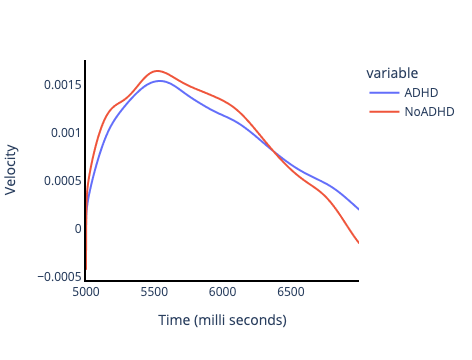

In [185]:
import plotly.express as px
import pandas as pd

# Use plotly express to create a line plot
fig = px.line(temp, x=list(range(5000,7000)), y=['ADHD','NoADHD'],
             labels={'value': 'Velocity', 'x': 'Time (milli seconds)'})

fig.update_layout(plot_bgcolor='white')
fig.update_xaxes(showline=True, linewidth=2, linecolor='black')
fig.update_yaxes(showline=True, linewidth=2, linecolor='black')
#fig.ylim(0, 0.002)

# Show the plot
fig.show()

In [83]:
features_pupils_t.distance.max(),features_pupils_t.distance.min()

(68465169.68583754, 3201.099203746759)

In [298]:
import matplotlib.pyplot as plt

In [303]:
features_pupils_t.columns

Index(['Max0_5000', 'Max5000_8000', 'TPS_start', 'TPS_end', 'TD', 'MaxV',
       'TotalV', 'MaxA', 'TotalA', 'PPS_AT', 'PPS_WM', 'adhd_identifier'],
      dtype='object')

In [306]:
df_corr = features_pupils_t[['TPS_end', 'TD', 'MaxV','TotalV', 'MaxA', 'TotalA', 'PPS_AT', 'PPS_WM', 'adhd_identifier']].corr()

In [18]:
le = LabelEncoder()
features_pupils_t['adhd_identifier'] = le.fit_transform(features_pupils_t['adhd_identifier'])

In [16]:
x = features_pupils_t.drop(columns=['adhd_identifier'])

In [17]:
from sklearn.preprocessing import MinMaxScaler

for col in x.columns:
    mms = MinMaxScaler()
    x[col] = mms.fit_transform(x[[col]])

In [315]:
#x.drop(columns=['TD','MaxV','TotalV'],inplace=True)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, features_pupils_t['adhd_identifier'], test_size=0.2)

In [52]:
lr = LogisticRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.74      0.72       605
           1       0.69      0.66      0.68       546

    accuracy                           0.70      1151
   macro avg       0.70      0.70      0.70      1151
weighted avg       0.70      0.70      0.70      1151



In [59]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [57]:
accuracy_score(y_test,y_pred)

0.7011294526498697

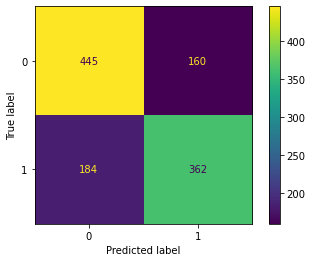

In [64]:
cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)
ConfusionMatrixDisplay(cm).plot()

### get cumulative distance travlled

In [289]:
features_pupils_t.groupby(by=['adhd_identifier']).agg({"TD":'mean'})

,TD
adhd_identifier,
0,10014.601732
1,10062.404596


In [76]:
features_pupils_t[['adhd_identifier','distance']].to_csv(r"C:\Users\Dheeraj Maroju\Dropbox\My PC (LAPTOP-9TEPO7IP)\Downloads\distance.csv",index=False)

### STATISTICAL TESTING

In [127]:
pupils_df

,index,Trial,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,...,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000,Subject_ID,ADHD_Identifier
0,0,1.0,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,-2.059392,...,-2.064614,-2.060034,-2.055441,-2.050835,-2.046218,-2.041589,-2.036949,-2.032298,1,ADHD
1,3,4.0,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,-0.698662,...,-0.642837,-0.645611,-0.648402,-0.65121,-0.654035,-0.656875,-0.659732,-0.662603,1,ADHD
2,7,8.0,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,0.230794,...,-0.222863,-0.224252,-0.225635,-0.227012,-0.228383,-0.229747,-0.231105,-0.232458,1,ADHD
3,45,46.0,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,1.081921,...,-1.654918,-1.655608,-1.656315,-1.657039,-1.657779,-1.658536,-1.659309,-1.660098,1,ADHD
4,61,62.0,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,0.293082,...,-0.725234,-0.730251,-0.735253,-0.740238,-0.745206,-0.750157,-0.75509,-0.760004,1,ADHD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5746,154,155.0,-1.07902,-1.079678,-1.080334,-1.080989,-1.081642,-1.082294,-1.082943,-1.083591,...,-0.354448,-0.355677,-0.356903,-0.358127,-0.359348,-0.360567,-0.361783,-0.362997,67,NoADHD
5747,155,156.0,-1.042429,-1.044024,-1.045618,-1.047211,-1.048803,-1.050395,-1.051986,-1.053576,...,1.78802,1.786976,1.785966,1.784989,1.784045,1.783134,1.782256,1.781412,67,NoADHD
5748,156,157.0,1.635427,1.635256,1.635104,1.634972,1.634859,1.634766,1.634691,1.634635,...,-0.763238,-0.761298,-0.759357,-0.757414,-0.755468,-0.753521,-0.751571,-0.74962,67,NoADHD
5749,157,158.0,-1.389628,-1.387164,-1.384694,-1.38222,-1.37974,-1.377255,-1.374764,-1.372268,...,-1.25869,-1.257325,-1.255967,-1.254617,-1.253274,-1.251939,-1.250612,-1.249293,67,NoADHD


In [132]:
aggregated_data = pupils_df.drop(columns=['index','Trial','Subject_ID']).groupby(by=['ADHD_Identifier']).agg('mean')

In [134]:
aggregated_data.reset_index(inplace=True)

In [135]:
aggregated_data

,ADHD_Identifier,Pupil_1_1,Pupil_1_2,Pupil_1_3,Pupil_1_4,Pupil_1_5,Pupil_1_6,Pupil_1_7,Pupil_1_8,Pupil_1_9,...,Pupil_1_7991,Pupil_1_7992,Pupil_1_7993,Pupil_1_7994,Pupil_1_7995,Pupil_1_7996,Pupil_1_7997,Pupil_1_7998,Pupil_1_7999,Pupil_1_8000
0,ADHD,-0.285313,-0.285558,-0.284546,-0.284035,-0.283573,-0.283331,-0.283127,-0.282956,-0.282816,...,-0.362513,-0.363239,-0.363963,-0.364685,-0.365405,-0.366123,-0.366838,-0.367551,-0.368261,-0.368968
1,NoADHD,-0.506518,-0.506686,-0.506853,-0.507020,-0.506859,-0.506703,-0.506500,-0.506302,-0.506111,...,-0.543619,-0.544017,-0.544414,-0.544810,-0.545207,-0.545602,-0.545997,-0.546392,-0.546786,-0.547180


In [147]:
adhd_aggregates = list(aggregated_data[aggregated_data['ADHD_Identifier']=='ADHD'].T[1:][0])
nonadhd_aggregates = list(aggregated_data[aggregated_data['ADHD_Identifier']!='ADHD'].T[1:][1])

In [149]:
adhd_aggregates

[-0.28531261336498465,
 -0.2855577727636428,
 -0.2845462750352119,
 -0.2840346966993295,
 -0.28357325692685437,
 -0.28333057619081314,
 -0.2831270804422577,
 -0.282955968069938,
 -0.28281591993081895,
 -0.2827102794570232,
 -0.28263476464765386,
 -0.2826024200695161,
 -0.2825991131245174,
 -0.2826264410552884,
 -0.28268188953958295,
 -0.2827716377513926,
 -0.282888441326018,
 -0.283031813462982,
 -0.2832050432048991,
 -0.28340393479205295,
 -0.28362805378511724,
 -0.28388433583772393,
 -0.2841707615842697,
 -0.2844784918496671,
 -0.28480972268157645,
 -0.28516402398659546,
 -0.2855409004883626,
 -0.2859432420101916,
 -0.2863678126014879,
 -0.28681363436517454,
 -0.2872802982565002,
 -0.2877705709991571,
 -0.28828081598494004,
 -0.28881061058730656,
 -0.28935953084262467,
 -0.2899293064588341,
 -0.29051701885608033,
 -0.2911221289532045,
 -0.29174470036738104,
 -0.29238161770514504,
 -0.2930352640225555,
 -0.29370700104951203,
 -0.2943976139675397,
 -0.2951036643618342,
 -0.295829784436

In [131]:
import scipy.stats as stats

In [150]:
# Combine data across all timestamps for each group
#combined_adhd_data = np.concatenate(adhd_data)
#combined_non_adhd_data = np.concatenate(non_adhd_data)

# Perform the Kolmogorov-Smirnov test
ks_result = stats.ks_2samp(adhd_aggregates, nonadhd_aggregates)

# Extract test statistic and p-value
statistic = ks_result.statistic
p_value = ks_result.pvalue

# Print results
print("Kolmogorov-Smirnov test statistic:", statistic)
print("Kolmogorov-Smirnov p-value:", p_value)

Kolmogorov-Smirnov test statistic: 0.2075
Kolmogorov-Smirnov p-value: 4.221260079606428e-151
